In [103]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset

In [104]:
import pandas as pd
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')


# convert from pandas dataframe to tensor
data = torch.tensor( iris[iris.columns[0:4]].values ).float()

# transform species to number
labels = torch.zeros(len(data), dtype=torch.long)
# labels[iris.species=='setosa'] = 0 # don't need!
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2
     


In [105]:
fakedata = np.tile(np.array([1,2,3,4]),(10,1)) + np.tile(10*np.arange(1,11),(4,1)).T
fakelabels = np.arange(10)>4
print(fakedata), print(' ')
print(fakelabels)

[[ 11  12  13  14]
 [ 21  22  23  24]
 [ 31  32  33  34]
 [ 41  42  43  44]
 [ 51  52  53  54]
 [ 61  62  63  64]
 [ 71  72  73  74]
 [ 81  82  83  84]
 [ 91  92  93  94]
 [101 102 103 104]]
 
[False False False False False  True  True  True  True  True]


In [106]:
fakedataLdr = DataLoader(fakedata, shuffle=True)
print(fakedataLdr.batch_size)

1


In [107]:
for i,oneSample in enumerate(fakedataLdr):
  print(i,oneSample,oneSample.shape)


0 tensor([[61, 62, 63, 64]]) torch.Size([1, 4])
1 tensor([[11, 12, 13, 14]]) torch.Size([1, 4])
2 tensor([[31, 32, 33, 34]]) torch.Size([1, 4])
3 tensor([[81, 82, 83, 84]]) torch.Size([1, 4])
4 tensor([[91, 92, 93, 94]]) torch.Size([1, 4])
5 tensor([[71, 72, 73, 74]]) torch.Size([1, 4])
6 tensor([[41, 42, 43, 44]]) torch.Size([1, 4])
7 tensor([[21, 22, 23, 24]]) torch.Size([1, 4])
8 tensor([[51, 52, 53, 54]]) torch.Size([1, 4])
9 tensor([[101, 102, 103, 104]]) torch.Size([1, 4])


In [108]:
fakeDataset = TensorDataset(torch.Tensor(fakedata), torch.Tensor(fakelabels))
fakeDataLdr = DataLoader(fakeDataset, shuffle=True)
print(fakeDataset.tensors)

(tensor([[ 11.,  12.,  13.,  14.],
        [ 21.,  22.,  23.,  24.],
        [ 31.,  32.,  33.,  34.],
        [ 41.,  42.,  43.,  44.],
        [ 51.,  52.,  53.,  54.],
        [ 61.,  62.,  63.,  64.],
        [ 71.,  72.,  73.,  74.],
        [ 81.,  82.,  83.,  84.],
        [ 91.,  92.,  93.,  94.],
        [101., 102., 103., 104.]]), tensor([0., 0., 0., 0., 0., 1., 1., 1., 1., 1.]))


In [109]:
for dat,lab in fakeDataLdr:
    print(dat,lab)

tensor([[51., 52., 53., 54.]]) tensor([0.])
tensor([[101., 102., 103., 104.]]) tensor([1.])
tensor([[21., 22., 23., 24.]]) tensor([0.])
tensor([[11., 12., 13., 14.]]) tensor([0.])
tensor([[61., 62., 63., 64.]]) tensor([1.])
tensor([[91., 92., 93., 94.]]) tensor([1.])
tensor([[41., 42., 43., 44.]]) tensor([0.])
tensor([[31., 32., 33., 34.]]) tensor([0.])
tensor([[81., 82., 83., 84.]]) tensor([1.])
tensor([[71., 72., 73., 74.]]) tensor([1.])


In [110]:
train_data, test_data, train_labels, test_labels = train_test_split(fakedata, fakelabels,test_size=.2)

train_data = TensorDataset(torch.Tensor(train_data),torch.Tensor(train_labels))
test_data = TensorDataset(torch.Tensor(test_data),torch.Tensor(test_labels))

train_loader = DataLoader(train_data, batch_size=4)
test_loader = DataLoader(test_data)

In [111]:
train_data,test_data, train_labels,test_labels = \
                              train_test_split(data, labels, train_size=.8, shuffle=True)


# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)


# finally, translate into dataloader objects
train_loader = DataLoader(train_data,shuffle=True,batch_size=12)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
     


In [112]:
# check sizes of data batches
for X,y in test_loader:
  print(X.shape,y.shape)

# X,y

torch.Size([30, 4]) torch.Size([30])


In [113]:
# a function that creates the ANN model

def createANewModel():

  # model architecture
  ANNiris = nn.Sequential(
      nn.Linear(4,64),   # input layer
      nn.ReLU(),         # activation unit
      nn.Linear(64,64),  # hidden layer
      nn.ReLU(),         # activation unit
      nn.Linear(64,3),   # output units
        )

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.SGD(ANNiris.parameters(),lr=.01)

  return ANNiris,lossfun,optimizer

In [114]:

# global parameter
numepochs = 500

def trainTheModel():

  # initialize accuracies as empties (not storing losses here)
  trainAcc = []
  testAcc  = []
  trainLosses = []

  # loop over epochs
  for epochi in range(numepochs):


    # loop over training data batches
    batchAcc = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = ANNiris(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # compute training accuracy just for this batch
      batchAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )

      loss = lossfun(yHat, y)
      trainLosses.append(loss.item())
    # end of batch loop...
    


    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    predlabels = torch.argmax( ANNiris(X),axis=1 )
    testAcc.append( 100*torch.mean((predlabels == y).float()).item() )

  # function output
  return trainAcc,testAcc, trainLosses

In [115]:
# create a model
ANNiris,lossfun,optimizer = createANewModel()

# train the model
trainAcc,testAcc, trainlosses = trainTheModel()    


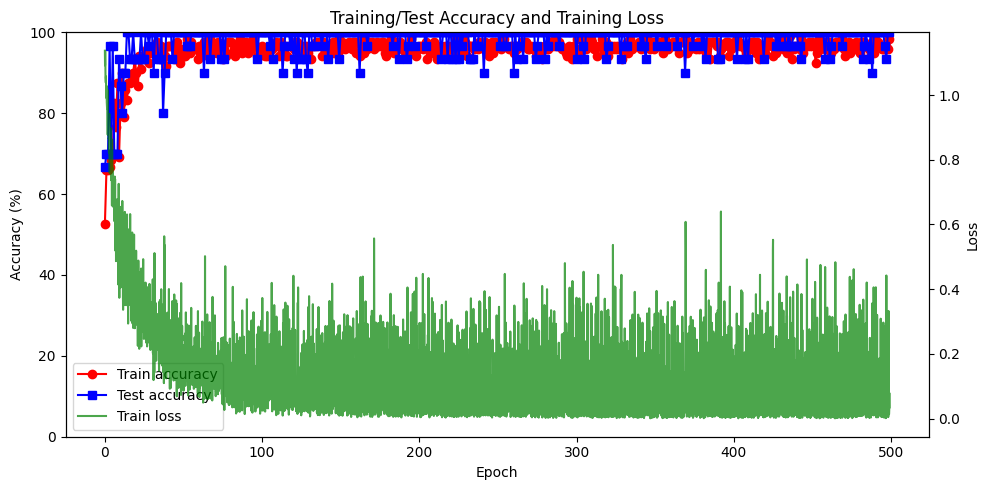

In [125]:
# plot accuracy and loss with separate y-axes
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(trainAcc, 'ro-', label='Train accuracy')
ax1.plot(testAcc, 'bs-', label='Test accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)

# ensure values are plain floats even if loss tensors were stored
loss_vals = [l.detach().cpu().item() if torch.is_tensor(l) else float(l) for l in trainlosses]
loss_x = np.linspace(0, numepochs - 1, len(loss_vals))

ax2 = ax1.twinx()
ax2.plot(loss_x, loss_vals, 'g-', alpha=.7, label='Train loss')
ax2.set_ylabel('Loss')

# Collect legend entries from both axes.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Training/Test Accuracy and Training Loss')
plt.tight_layout()
plt.show()